# PROYECTO: Logística Predictiva
## Optimizando la Entrega en E-commerce para Proteger la Reputación de Marca

### 1. Contexto del Proyecto
Una empresa internacional de comercio electrónico especializada en productos tecnológicos desea extraer conocimientos clave de su base de datos de clientes. El objetivo es aplicar técnicas avanzadas de **Machine Learning** para analizar el comportamiento de sus usuarios y optimizar sus operaciones, centrándose en la puntualidad de las entregas.

### 2. Contenido del Dataset
El conjunto de datos utilizado consta de **10.999 observaciones** y **12 variables**. A continuación, se detalla la información contenida en cada columna:

* **ID**: Número de identificación del cliente.
* **Warehouse block (Bloque del almacén)**: El almacén principal está dividido en bloques (A, B, C, D, E).
* **Mode of shipment (Modo de envío)**: Método de transporte (Barco, Avión o Carretera).
* **Customer care calls (Llamadas a atención al cliente)**: Número de consultas realizadas por el cliente sobre su envío.
* **Customer rating (Valoración)**: Calificación del cliente (1: peor, 5: mejor).
* **Cost of the product (Coste)**: Precio del producto en USD.
* **Prior purchases (Compras previas)**: Número de pedidos anteriores del cliente.
* **Product importance (Importancia)**: Categorización del producto (baja, media, alta).
* **Gender (Género)**: Sexo del cliente (Masculino/Femenino).
* **Discount offered (Descuento)**: Rebaja aplicada al producto.
* **Weight in gms (Peso)**: Peso físico del paquete en gramos.
* **Reached on time (Llegada a tiempo)**: **Variable objetivo (Target)**. El valor **1** indica que el producto **NO** llegó a tiempo (retraso), mientras que el **0** indica que llegó a tiempo.

### 3. Análisis Inicial y Objetivos de Negocio

#### Estructura de los datos (Resumen de df.info()):
- **Volumen**: 10.999 registros y 12 campos (cumple con los requisitos del proyecto).
- **Calidad**: No se detectan valores nulos iniciales, lo que permite un flujo de trabajo de limpieza directo.
- **Tipos**: Mezcla de variables categóricas (objetos) y numéricas (enteros), lo que requerirá preprocesamiento y *encoding* posterior.

#### Preguntas de Investigación (Business Case):
1. ¿Existe un "cuello de botella" logístico en algún bloque de almacén específico?
2. ¿Qué modo de envío presenta la mayor tasa de incumplimiento?
3. ¿Cómo influye el peso y el coste del producto en la prioridad de entrega?
4. ¿Existe una correlación entre los descuentos agresivos y los retrasos en los envíos?
5. ¿Podemos predecir un retraso antes de que ocurra para emitir una alerta proactiva al cliente?

#### Estado de la Variable Objetivo:
Tras un análisis inicial, se observa que:
- **1 (Retraso)**: 59.7%
- **0 (A tiempo)**: 40.3%
*Conclusión*: La empresa tiene una tasa de retraso muy elevada. El modelo se enfocará en detectar ese 60% de fallos para que el equipo de atención al cliente pueda actuar de forma preventiva[cite: 2].

In [2]:
# Tratamiento de datos
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
#from sklearn.decomposition import PCA
#from sklearn.pipeline import make_pipeline
#from sklearn.preprocessing import StandardScaler
#from sklearn.preprocessing import scale

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("../data/shipping_data.csv")

df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [4]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [6]:
# observaciones: 10.999 registros

# cols: 12 variables

# no se detectan valores nulos

# tipos de datos:
# object (veriables categóricas): Warehouse_block, Mode_of_Shipment, Product_importance, Gender.
# int64: ID, Customer_care_calls, Customer_rating, Cost_of_the_Product, Prior_purchases, Discount_offered, Weight_in_gms

# target: Reached.on.Time_Y.N (Binaria: 0 o 1).


In [7]:
# me pregunto:

# ¿existe un 'cuello de botella' en algún almacén (Warehouse_block) específico?
# ¿el modo de envío (avión, barco, carretera) influye proporcionalmente en los retrasos?
# ¿los clientes con más compras previas (fidelizados) reciben mejor servicio o sufren más retrasos?
# ¿hay una correlación entre el peso del producto y la probabilidad de llegar tarde?
# ¿cómo impacta el descuento ofrecido? ¿los productos muy rebajados se priorizan menos?

In [8]:
# esto te dirá cuántos paquetes llegaron tarde (1) y cuántos a tiempo (0)
df['Reached.on.Time_Y.N'].value_counts(normalize=True).sort_index() * 100

# .sort_index() ordena las filas basándose en las etiquetas (el 0 y el 1) en lugar de los valores

Reached.on.Time_Y.N
0    40.330939
1    59.669061
Name: proportion, dtype: float64

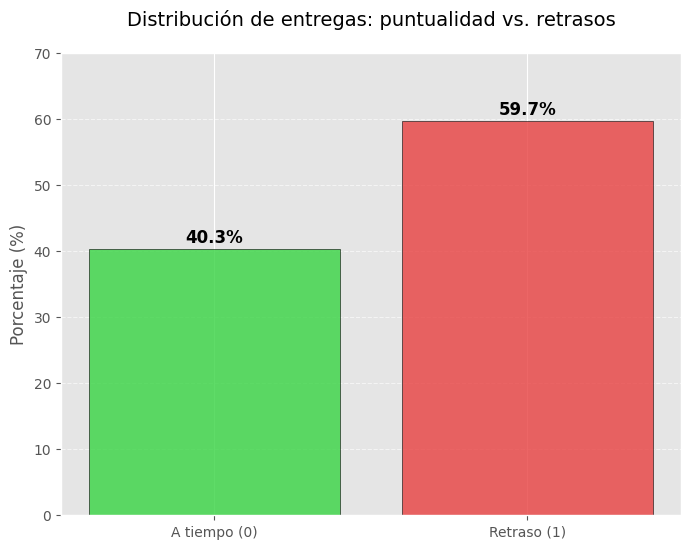

In [9]:
# quiero visualizarlo


data = {'Estado': ['A tiempo (0)', 'Retraso (1)'],
        'Porcentaje': [40.3, 59.7]}

df_plot = pd.DataFrame(data)


plt.figure(figsize=(8, 6))
colors = ["#37d442", "#e84040"] # Azul para puntual, rojo para retraso
plt.bar(df_plot['Estado'], df_plot['Porcentaje'], color=colors, edgecolor='black', alpha=0.8)

# Añadir etiquetas de datos
for i, val in enumerate(df_plot['Porcentaje']):
    plt.text(i, val + 1, f'{val}%', ha='center', fontweight='bold', fontsize=12)

plt.title('Distribución de entregas: puntualidad vs. retrasos', fontsize=14, pad=20)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.ylim(0, 70)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [10]:
# target

# el 59.7% de los envíos llegan con retraso. Es una cifra crítica para el negocio
# supone un problema grave de reputación y experiencia de usuario

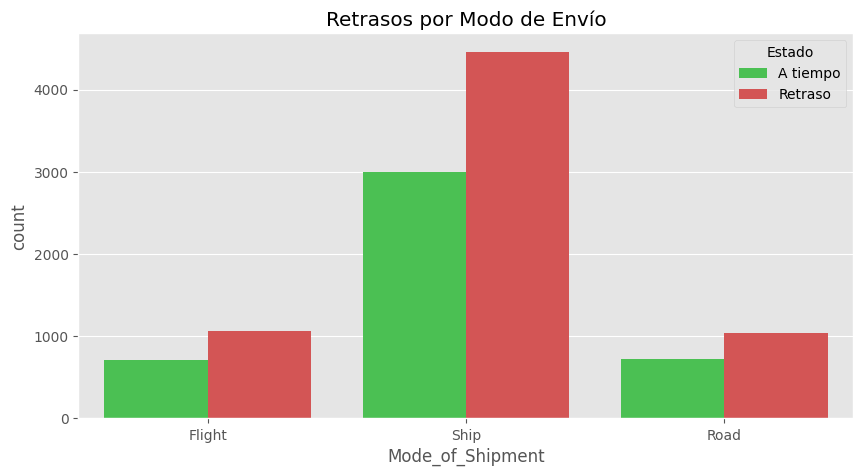

In [11]:
# ¿Influye el modo de envío en los retrasos?
plt.figure(figsize=(10, 5))
sns.countplot(x='Mode_of_Shipment', hue='Reached.on.Time_Y.N', data=df, palette=['#37d442', '#e84040'])
plt.title('Retrasos por Modo de Envío')
plt.legend(title='Estado', labels=['A tiempo', 'Retraso'])
plt.show()



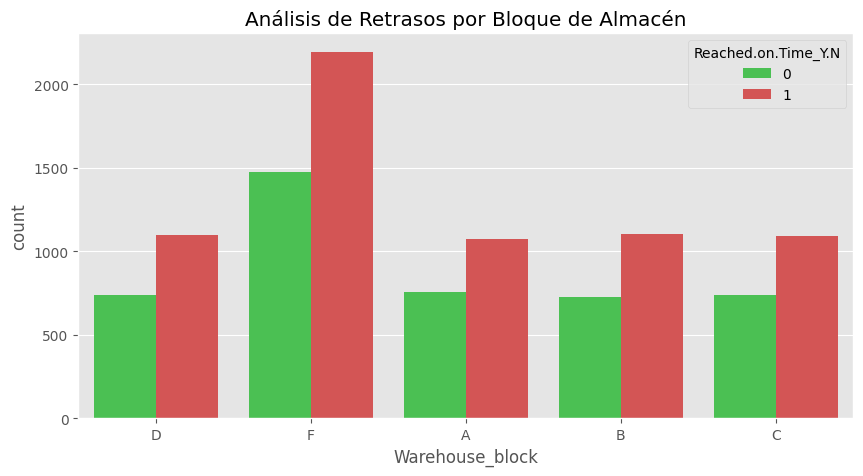

In [12]:
# ¿Hay problemas en algún almacén (Warehouse block) específico?
plt.figure(figsize=(10, 5))
sns.countplot(x='Warehouse_block', hue='Reached.on.Time_Y.N', data=df, palette=['#37d442', '#e84040'])
plt.title('Análisis de Retrasos por Bloque de Almacén')
plt.show()

In [13]:
# Resumen estadístico de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,10999.0,5500.000000,3175.282140,1.0,2750.5,5500.0,8249.5,10999.0
Customer_care_calls,10999.0,4.054459,1.141490,2.0,3.0,4.0,5.0,7.0
Customer_rating,10999.0,2.990545,1.413603,1.0,2.0,3.0,4.0,5.0
Cost_of_the_Product,10999.0,210.196836,48.063272,96.0,169.0,214.0,251.0,310.0
Prior_purchases,10999.0,3.567597,1.522860,2.0,3.0,3.0,4.0,10.0
Discount_offered,10999.0,13.373216,16.205527,1.0,4.0,7.0,10.0,65.0
Weight_in_gms,10999.0,3634.016729,1635.377251,1001.0,1839.5,4149.0,5050.0,7846.0
Reached.on.Time_Y.N,10999.0,0.596691,0.490584,0.0,0.0,1.0,1.0,1.0


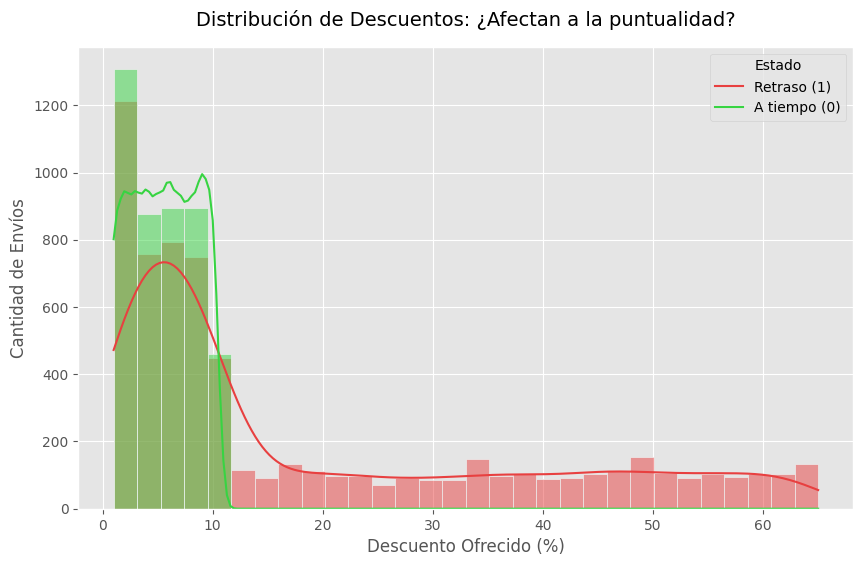

In [16]:
plt.figure(figsize=(10, 6))
# Usamos kde=True para ver la curva de distribución
sns.histplot(data=df, x='Discount_offered', hue='Reached.on.Time_Y.N', bins=30, kde=True, palette=['#37d442', '#e84040'])
plt.title('Distribución de Descuentos: ¿Afectan a la puntualidad?', fontsize=14, pad=15)
plt.xlabel('Descuento Ofrecido (%)')
plt.ylabel('Cantidad de Envíos')
plt.legend(title='Estado', labels=['Retraso (1)', 'A tiempo (0)'])
plt.show()

# Comentario de negocio: 
# Fíjate bien en el gráfico resultante. En este dataset, suele ocurrir que los descuentos 
# muy altos coinciden casi siempre con envíos retrasados. ¡Ese es un titular buenísimo!

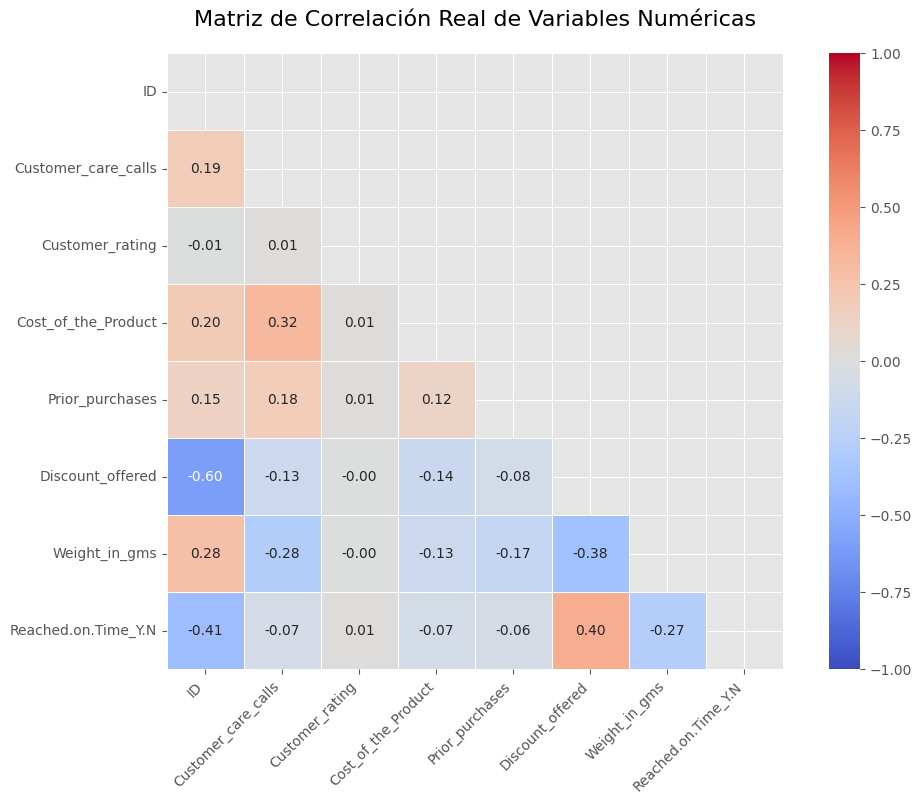

In [17]:
# 1. Seleccionamos solo las columnas numéricas reales de tu dataframe
numericas = df.select_dtypes(include=['int64', 'float64'])

# 2. Calculamos la matriz de correlación real
matriz_correlacion = numericas.corr()

# 3. Dibujamos el Heatmap
plt.figure(figsize=(12, 8))
# Usamos una máscara para tapar la mitad superior (opcional, pero queda muy pro)
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool))

sns.heatmap(matriz_correlacion, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            square=True, 
            linewidths=.5)

plt.title('Matriz de Correlación Real de Variables Numéricas', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

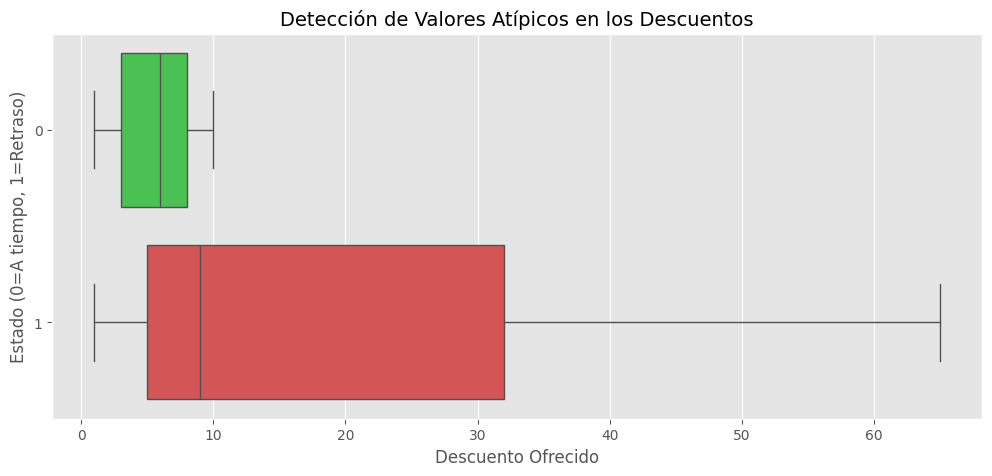

In [18]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Discount_offered', y='Reached.on.Time_Y.N', orient='h', palette=['#37d442', '#e84040'])
plt.title('Detección de Valores Atípicos en los Descuentos', fontsize=14)
plt.xlabel('Descuento Ofrecido')
plt.ylabel('Estado (0=A tiempo, 1=Retraso)')
plt.show()